In [1]:
import pandas as pd
import re
import platform
import os
import sys
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import csv
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from utils import *
pd.set_option('display.max_colwidth', None)

In [2]:
use_cuda = torch.cuda.is_available()
print(use_cuda)
device = torch.device("cuda")
# to use gpu

True


In [3]:
PROJECT_DIR = '../'            # IMAGE-CAPTIONING-DL

In [4]:
current_cwd = os.getcwd()

In [5]:
if platform.system() == 'Windows':
    lst = current_cwd.split('\\', 2)
    new_cwd = '/'.join(lst[:2])
    os.chdir(new_cwd)
    sys.path.append(new_cwd + '/code')
    IMAGES_PATH = 'data/flickr8k/Images'
    CAPTIONS_PATH = 'data/flickr8k/captions.txt'
    print("IMAGES_PATH (Windows):", IMAGES_PATH)
else:
    IMAGES_PATH = os.path.join('../', 'data', 'flickr8k', 'Images')
    CAPTIONS_PATH = os.path.join('../', 'data', 'flickr8k', 'captions.txt')
    print("IMAGES_PATH (Linux/WSL):", IMAGES_PATH)

IMAGES_PATH (Linux/WSL): ../data/flickr8k/Images


In [6]:
data = pd.read_csv(CAPTIONS_PATH)
data.head(2)

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .


#### 1.Using CNN to extract features from images, this step has been set up in *image_features_extraction* with _Img2Vec_

In [7]:
images_data = data.drop_duplicates(subset=['image'])
# only get 1 name of same image

In [8]:
# Add the path to the feature_extraction directory
sys.path.append(os.path.abspath('../feature_extraction/image_features_extraction'))

# Now you can import Img2Vec
from Img2Vec import Img2Vec

In [9]:
features_image = {}
cnt = 0
img2vec = Img2Vec('vgg16bn')
for img in images_data.image:
    features_image[img] = img2vec.get_vector(IMAGES_PATH + '/' + img)
    cnt += 1
    if cnt % 1000 == 0:
        print(f"Completed {cnt} images")


Completed 1000 images
Completed 2000 images
Completed 3000 images
Completed 4000 images
Completed 5000 images
Completed 6000 images
Completed 7000 images
Completed 8000 images


In [10]:
tensor = features_image['1000268201_693b08cb0e.jpg']
output_feature_size = len(tensor)
print(output_feature_size)
features_image['1000268201_693b08cb0e.jpg'].shape

4096


torch.Size([4096])

#### 2.Handling Text

In [11]:
with open(os.path.join(PROJECT_DIR,'data','flickr8k', 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()
    
''' Create a dictionary to map 1 image with multiple caps '''    
mapping = {}
for line in tqdm(captions_doc.split('\n')):
    img_and_cap = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = img_and_cap[0], img_and_cap[1:]
    # convert caption list to string
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)
# print(mapping['1000268201_693b08cb0e.jpg'])
# print(len(mapping))

100%|██████████| 40456/40456 [00:00<00:00, 1185910.11it/s]


In [12]:
def clean_and_tokenize(cap):
    # for key, cap_list in mapping.items() 
    # cap = cap.rstrip('.')
    cap = cap.strip('"')
    # tokenize
    cap = cap.split()
    # convert to lower case
    cap = [word.lower() for word in cap]
    # remove tokens with numbers in them
    # cap = [word for word in cap if word.isalpha()]   long-neck be deleted
    cap = [word for word in cap if re.match(r'^[a-zA-Z-]+$', word)]
    cap = '<startseq> ' + ' '.join([word for word in cap if len(word) >1]) + ' <endseq>'
    cap = cap.split()
    return cap
print(clean_and_tokenize('"Long-necked , flying white bird grazes water with black legs ."'))

['<startseq>', 'long-necked', 'flying', 'white', 'bird', 'grazes', 'water', 'with', 'black', 'legs', '<endseq>']


In [13]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)
print(len(all_captions))
all_captions[:6]

40455


['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .',
 'A black dog and a spotted dog are fighting']

In [14]:
import random
random.seed(1)
def train_test_split(mapping, train_ratio=0.85, val_ratio = 0.1, test_ratio = 0.05):
    """Splits a mapping dictionary into training and testing sets.
    Args:
        mapping: The input mapping dictionary.
    Returns:
        A tuple of training, validation and testing mappings.
    """

    image_ids = list(mapping.keys())
    random.shuffle(image_ids)

    num_total_imgs = len(image_ids)
    train_index = int(train_ratio * len(image_ids))
    val_index = int((train_ratio+val_ratio) * len(image_ids))

    train_image_ids = image_ids[:train_index]
    val_image_ids = image_ids[train_index:val_index]
    test_image_ids = image_ids[val_index:]

    train_mapping = {image_id: mapping[image_id] for image_id in train_image_ids}
    val_mapping = {image_id: mapping[image_id] for image_id in val_image_ids}
    test_mapping = {image_id: mapping[image_id] for image_id in test_image_ids}

    return train_mapping, val_mapping, test_mapping
train_mapping, val_mapping, test_mapping = train_test_split(mapping)
print(len(train_mapping), len(val_mapping), len(test_mapping))

6877 809 405


In [15]:
def TrainDescriptionTokens(mapping = train_mapping):
    number_of_train_lines = 0
    train_token_to_occurrences_dict = {}
    
    for image_id, captions in mapping.items():
        for caption in captions:
            # Tokenize the caption using clean_and_tokenize
            
            tokens = clean_and_tokenize(cap= caption)
            # Count the occurrences of each token
            for token in tokens:
                if token in train_token_to_occurrences_dict:
                    train_token_to_occurrences_dict[token] += 1
                else:
                    train_token_to_occurrences_dict[token] = 1
            
            number_of_train_lines += 1
    print(f"TrainDescriptionTokens(): number_of_train_lines = {number_of_train_lines}")
    # with open(os.path.join('../', 'data', 'occurrence_train.txt'), "w") as f:
    #     for token, occurrences in train_token_to_occurrences_dict.items():
    #         f.write(f"{token}\t{occurrences}\n")

    return train_token_to_occurrences_dict
train_token_to_occurrences_dict = TrainDescriptionTokens(train_mapping)
# print(len(train_token_to_occurrences_dict))
# 

TrainDescriptionTokens(): number_of_train_lines = 34385


In [16]:
# ''' Remove the words that appeared just once '''
# print(len(train_token_to_occurrences_dict))
# single_occurrence_words = []
# for word, occurrences in train_token_to_occurrences_dict.items():
#     if occurrences < 2:
#         single_occurrence_words.append(word)
# for word in single_occurrence_words:
#     train_token_to_occurrences_dict.pop(word)
# print(len(train_token_to_occurrences_dict))


Sort the words in reverse order of frequency and write our vocabulary

In [17]:
vocabulary_filepath = os.path.join(PROJECT_DIR, 'data', 'vocab.txt')
sorted_tokens = sorted(train_token_to_occurrences_dict.items(), key=lambda x: x[1], reverse=True) 
sorted_tokens = [('<unk>', 0), ('<notset>', 0)] + sorted_tokens

with open(vocabulary_filepath, 'w+') as output_file:
    output_file.write("index,word,frequency\n")
    for index, token in enumerate(sorted_tokens):
        output_file.write("{},{},{}\n".format(index, token[0], token[1]))

In [18]:
def LoadVocabulary(vocabularyFilepath = vocabulary_filepath):
    word_to_index_dict = {}
    index_to_word_dict = {}
    vocabDf = pd.read_csv(vocabularyFilepath)
    for i, row in vocabDf.iterrows():
        index = row['index']
        word = row['word']
        word_to_index_dict[word] = index
        index_to_word_dict[index] = word
    return word_to_index_dict, index_to_word_dict
word_to_index_dict, index_to_word_dict = LoadVocabulary(vocabulary_filepath)


In [19]:
print(word_to_index_dict['<unk>'])
print(word_to_index_dict['<notset>'])
print(word_to_index_dict['<startseq>'])
print(word_to_index_dict['<endseq>'])
print(index_to_word_dict[0])
print(index_to_word_dict[1])
print(index_to_word_dict[3])
print(index_to_word_dict[4])

0
1
2
3
<unk>
<notset>
<endseq>
in


In [20]:
max_length = max(len(caption.split()) for caption in all_captions)
max_length

37

In [21]:
description_maximum_length = 40

In [22]:
def ConvertTokensListToIndices(tokens, word_to_index_dict, maximum_length):
    ''' Convert all the token of a caption of an image to ârray of occurrence'''
    
    indices = [word_to_index_dict['<notset>']] * maximum_length                # set all the positions to <notset>

    for token_idx, token in enumerate(tokens):
        index = word_to_index_dict.get(token, word_to_index_dict['<unk>']) # If the word is not in the dictionary, fall back to '<unk>'
        indices[token_idx] = index
    # if len(tokens) < maximum_length:
    #     indices[len(tokens)] = word_to_index_dict['<endseq>']
    return indices

pretokenized_descriptions_filepath = os.path.join(PROJECT_DIR, 'data', 'token_describ.csv')

with open(pretokenized_descriptions_filepath, 'w+') as outputFile:
    # Write the header
    outputFile.write("image")
    for wordNdx in range(description_maximum_length):
        outputFile.write(",w{}".format(wordNdx))
    outputFile.write("\n")

    # Loop through the lines of the descriptions file
    with open(CAPTIONS_PATH, 'r') as descriptionsFile:

        for line in descriptionsFile.readlines()[1:]:
            line = line.strip()
            line = line.split(',')
            # print(line)
            image_filename, description = line[0], line[1]
            # Tokenize the description
            tokens = clean_and_tokenize(description)

            # Convert the list of tokens to a list of indices
            indices = ConvertTokensListToIndices(tokens,
                                                 word_to_index_dict,
                                                 description_maximum_length)
            outputFile.write(image_filename)
            for i in range(len(indices)):
                outputFile.write(",{}".format(indices[i]))
            outputFile.write("\n")

In [23]:
tokenized_descriptionsDf = pd.read_csv(pretokenized_descriptions_filepath)
tokenized_descriptionsDf.head(2)
# 1 is notset


,image,w0,w1,w2,w3,w4,w5,w6,w7,w8,...,w30,w31,w32,w33,w34,w35,w36,w37,w38,w39
0,1000268201_693b08cb0e.jpg,2,44,4,86,173,7,120,51,403,...,1,1,1,1,1,1,1,1,1,1
1,1000268201_693b08cb0e.jpg,2,19,306,64,193,119,3,1,1,...,1,1,1,1,1,1,1,1,1,1


##### Create a word embedding with the word2vec (Continuous Bag of Words) algorithm¶
Encoding the words with an arbitrary index from a vocabulary dictionary is easy, but it comes with a cost. To translate this encoding into a tensor form would yield to a one-hot encoding

 It would be advantageous to have an encoding that represents words as numerical vectors that transpose word meaning similarities into vector similarities.

In [24]:
training_description_indices = []
for t in tokenized_descriptionsDf.itertuples():
    filename = t[1]
    if filename in list(train_mapping.keys()):
        training_description_indices.append(list(t[2:]))
print("training_description_indices[0:2] = {}".format(training_description_indices[0:2]))
special_tokens = [word_to_index_dict['<startseq>'], word_to_index_dict['<endseq>'], word_to_index_dict['<unk>'], word_to_index_dict['<notset>']]

def is_only_special_tokens(description_indices):
    '''Check if cap just all special tokens'''
    return all(word_idx in special_tokens for word_idx in description_indices)

for description_indices in training_description_indices:
    if is_only_special_tokens(description_indices):
        print("Only special tokens: ", description_indices)
        continue  
filtered_training_description_indices = [description for description in training_description_indices if not is_only_special_tokens(description)]
training_description_indices = filtered_training_description_indices


# erased the caps that have only special
print("ERASED ")
for description_indices in training_description_indices:
    if is_only_special_tokens(description_indices):
        print("Only special tokens: ", description_indices)
        continue  


training_description_indices[0:2] = [[2, 44, 4, 86, 173, 7, 120, 51, 403, 12, 399, 4, 28, 5949, 681, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 19, 306, 64, 193, 119, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
Only special tokens:  [2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Only special tokens:  [2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
ERASED 


#### 3. Create a dataset class that generates an embedding dictionary

In [25]:
# context mean x words around important word
class ContextToWordDataset(Dataset):
    def __init__(self,
                 training_descriptions_indices,
                 index_to_word_dict,
                 word_to_index_dict,
                 contextLength):
        self.training_descriptions_indices = training_descriptions_indices
        self.index_to_word_dict = index_to_word_dict
        self.word_to_index_dict = word_to_index_dict
        self.contextLength = contextLength

    def __len__(self):
        return len(self.training_descriptions_indices)

    ''' The method below will return a center word, and several context words around (in indices)'''
    def __getitem__(self, idx):
        # print(self.training_descriptions_indices[idx])
        description_indices = self.training_descriptions_indices[idx]        # get cap but presentation is full of indices from created vocab
        last_acceptable_center_index = len(description_indices) - 1          # prevent the center word is out of bound
        
        if self.word_to_index_dict['<endseq>'] in description_indices:
            for position, index in enumerate(description_indices):
                ## if meet"<endseq>", re define the index of last element
                if index == self.word_to_index_dict['<endseq>']:
                    # print("Last: " , position)
                    last_acceptable_center_index = position
                 
        # randomly select a target word
        # target_idx = random.choice(range(last_acceptable_center_index + 1))
     
        while True:
            target_idx = random.choice(range(last_acceptable_center_index+1))
            # remove noise, <unk> not a good center word
            if (description_indices[target_idx] != self.word_to_index_dict['<unk>']) and\
               (description_indices[target_idx] != self.word_to_index_dict['<startseq>']) and\
               (description_indices[target_idx] != self.word_to_index_dict['<endseq>']):
                break
        
        # print("random: ", target_idx)
        
        context_around_idxs_Tsr =  torch.ones((2 * self.contextLength)).long() * self.word_to_index_dict['<notset>']
        
        running_idx = target_idx - int(self.contextLength)    # maybe negative      
        counter = 0
        # consider all word around target
        while counter < 2 * self.contextLength:
            # print("Running ID: ", running_idx)
            if running_idx != target_idx:
                # prevent index is negative or out of bound
                if running_idx >= 0 and running_idx < len(description_indices):
                    context_around_idxs_Tsr[counter] = description_indices[running_idx]
                counter += 1
            running_idx += 1
        target_center_word_idx = description_indices[target_idx]
        if target_center_word_idx >= len(self.word_to_index_dict):
            raise ValueError(f"Invalid target index: {target_center_word_idx}")
        return context_around_idxs_Tsr,  target_center_word_idx
        

train_dataset = ContextToWordDataset(training_description_indices, index_to_word_dict,
                word_to_index_dict, contextLength=3)

In [26]:
# random.seed(1)
sample_data_0 = train_dataset[0]    # test one cap
sample_words_0 = [index_to_word_dict[i] for i in sample_data_0[0].tolist()]        # change to words through indices
center_word_0 = index_to_word_dict[sample_data_0[1]]
print ("sample_words_0 = {}; center_word_0 = {}".format(sample_words_0, center_word_0))
sample_data_1 = train_dataset[1]
sample_words_1 = [index_to_word_dict[i] for i in sample_data_1[0].tolist()]
center_word_1 = index_to_word_dict[sample_data_1[1]]
print ("sample_words_1 = {}; center_word_1 = {}".format(sample_words_1, center_word_1))

sample_words_0 = ['child', 'in', 'pink', 'is', 'climbing', 'up']; center_word_0 = dress
sample_words_1 = ['girl', 'going', 'into', 'building', '<endseq>', '<notset>']; center_word_1 = wooden


Create model that try to predict important word, base on the contextwords around, this will calculate loss and re-upgrade w,b to get the best w,b

In [27]:
class CenterWordPredictor(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension):    # vocab size = len(word_to_index_dict)
        super(CenterWordPredictor, self).__init__()
        # create an Embedding Layer
        self.embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        # create a Linear layer
        self.decoderLinear = torch.nn.Linear(embedding_dimension, vocabulary_size)           #?
        self.embedding_dim = embedding_dimension
        self.embedding_dimension = embedding_dimension
    def forward(self, contextTsr):
        '''
        processes the context tensor to compute the logits for each word in the vocabulary, 
        representing the model's prediction of the center word based on the provided context.
        '''
        if torch.any(contextTsr >= len(self.embedding.weight)):
            raise ValueError("Index out of bounds in context tensor")
        embedding = self.embedding(contextTsr)  # (batch_size, context_length, embedding_dimension)
        # Average over context words: (batch_size, context_length, embedding_dimension) 
        embedding = torch.mean(embedding, dim=1)
        # -> (batch_size, embedding_dimension): a reprenstative vector for context_tensor
        
        
        # Decoding, weight, bias in this layer will be random, loss function and backpropagate will fix them later
        outputTsr = self.decoderLinear(embedding)   # logit of each word, size (N, vocab_size)
        return outputTsr
vocabulary_size = len(word_to_index_dict)
print(f"Vocabulary size: {vocabulary_size}")
embedding_dimension = 128    
word_embedder = CenterWordPredictor(vocabulary_size, embedding_dimension)
if use_cuda:
    word_embedder = word_embedder.cuda()

Vocabulary size: 8205


In [28]:
import wandb


wandb.init(
    project = "ProjectContextWords",
    config={
        "learning_rate": 0.0001,
        "batch_size": 32,
        "epochs": 100,
        "embedding_dim": 128,
        "optimizer" : "ADAM",
        "train_ratio":0.85,
        "val_ratio": 0.1,

})

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: vubkk67 (vubkk67-hanoi-university-of-science-and-technology). Use `wandb login --relogin` to force relogin


In [29]:
model_embedding_path = os.path.join(PROJECT_DIR, 'models', 'word_embedder_model.pth')

#### Run this model once to get word_embedder

In [30]:
# random.seed(1)
# '''
# Model will be trained to predict centerword from context.
# Backpropagation to fix the weight, bias in 2 matrices above
# Create a model that obtain an embedding matrix of each word
# '''
# word_embedder_parameters = filter(lambda p: p.requires_grad, word_embedder.parameters())
# # Lọc và giữ lại chỉ những tham số của mô hình có requires_grad=True, 
# # tức là các tham số mà mô hình cần tối ưu trong quá trình huấn luyện.

# optimizer = torch.optim.Adam(word_embedder_parameters, lr=0.0001)

# # logit will be passed to lossFcn, inside will have softmax
# lossFcn = nn.CrossEntropyLoss()
# train_dataLoader = DataLoader(train_dataset, batch_size=32, shuffle=True) # when call, return one batch dataset

# lowestTrainLoss = sys.float_info.max
# for epoch in range(1,1000+1):     # put max epoch around 1000
#     word_embedder.train()
#     loss_sum = 0.0
#     number_of_batches = 0        # num batches have been sent
#     for (context_around_idxs_Tsr, target_center_word_ndx) in train_dataLoader:
#         if number_of_batches % 50 == 0 and number_of_batches > 0:
#             print (".", end="", flush=True)
            
#         # print("Vocabulary size:", len(self.embedding.weight))
#         if use_cuda:
#             context_around_idxs_Tsr = context_around_idxs_Tsr.cuda()
#             target_center_word_ndx = target_center_word_ndx.cuda()
            
#         predicted_center_word_ndx = word_embedder(context_around_idxs_Tsr)
#         # calculating Loss
#         optimizer.zero_grad()
        
#         # print(predicted_center_word_ndx.shape)  # Should be (N, vocab_size)
#         # print(target_center_word_ndx.shape)    # Should be (N,)
#         loss = lossFcn(predicted_center_word_ndx, target_center_word_ndx)
#         loss.backward()
        
#         optimizer.step()    # upgrade weight
        
#         loss_sum += loss.item()
#         number_of_batches += 1
#     train_loss = loss_sum/number_of_batches
#     if train_loss < lowestTrainLoss:
#         lowestTrainLoss = train_loss
#         torch.save(word_embedder.state_dict(), model_embedding_path)
#     print ("\nepoch {}: train_loss = {}".format(epoch, train_loss))
#     wandb.log({'Train_loss': train_loss})
# wandb.finish()


In [31]:
word_embedder_init = CenterWordPredictor(vocabulary_size, embedding_dimension)
word_embedder_init.load_state_dict(torch.load(model_embedding_path))
word_embedder_init = word_embedder_init.cuda()
model_embedding_path_to_change = os.path.join(PROJECT_DIR, 'models', 'word_embedder_model_copy.pth')
# to prevent the change in word_embedder

In [32]:
word_embedder = CenterWordPredictor(vocabulary_size, embedding_dimension)
word_embedder.load_state_dict(torch.load(model_embedding_path_to_change))


<All keys matched successfully>

In [33]:
if use_cuda:
    word_embedder = word_embedder.cuda()

In [34]:
initial_state_dict = {k: v.clone() for k, v in word_embedder_init.state_dict().items()}

In [35]:
# ''' Write to a csv file embedding matrix just to see, modify if anything goes incorrectly'''
# words2vec_dictionary_filepath = os.path.join(PROJECT_DIR, 'data', 'words2vec.csv')
# with open(words2vec_dictionary_filepath, 'w+') as word2vecFile:
#     # Write the header
#     word2vecFile.write("word")
#     for embedding_idx in range(embedding_dimension):
#         word2vecFile.write(",e{}".format(embedding_idx))
#     word2vecFile.write("\n")


#     for index, word in index_to_word_dict.items():
#         wordEmbeddingList = word_embedder.embedding.weight[index].tolist()
#         word2vecFile.write(word)
#         for coef in wordEmbeddingList:
#             word2vecFile.write(",{}".format(str(coef)))
#         word2vecFile.write("\n")

In [36]:
# word2vecDf = pd.read_csv(words2vec_dictionary_filepath)
# word_to_embedding_dict = {word2vecDf.iloc[i]['word'] : word2vecDf.loc[i, 'e0': 'e{}'.format(embedding_dimension - 1)].tolist()
#                               for i in range(len(word2vecDf))}


In [37]:
# print ("word_to_embedding_dict['dog'] = {}".format(word_to_embedding_dict['dog']))
# print()
# print ("word_to_embedding_dict['dance'] = {}".format(word_to_embedding_dict['dance']))


#### 4.Training an LSTM network

In [38]:
'''Get the name of dictionary of filename : {indices of words}'''
def ImageFilenameToTokenizedDescriptionsList(descriptionsDF):
    image_filename_to_tokenized_description = {}
    for i, row in descriptionsDF.iterrows():
        filename = descriptionsDF.iloc[i][0]
        tokenized_description = list(descriptionsDF.iloc[i][1:])
        if filename in image_filename_to_tokenized_description:
            image_filename_to_tokenized_description[filename].append(tokenized_description)
        else:
            image_filename_to_tokenized_description[filename] = [tokenized_description]
    return image_filename_to_tokenized_description

# Create the tokenized descriptions mapping
image_filename_to_tokenized_descriptions_list = ImageFilenameToTokenizedDescriptionsList(tokenized_descriptionsDf)
print(image_filename_to_tokenized_descriptions_list['1002674143_1b742ab4b8.jpg'])


[[np.int64(2), np.int64(39), np.int64(19), np.int64(185), np.int64(4), np.int64(575), np.int64(107), np.int64(4), np.int64(48), np.int64(12), np.int64(610), np.int64(1209), np.int64(10), np.int64(62), np.int64(218), np.int64(4), np.int64(1172), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], [np.int64(2), np.int64(39), np.int64(19), np.int64(7), np.int64(50), np.int64(4), np.int64(48), np.int64(12), np.int64(54), np.int64(610), np.int64(1209), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), n

In [39]:
print(len(word_embedder.embedding(torch.tensor(0).cuda())))

128


Set up dataset first

In [40]:
class CaptionGenerationDataset(Dataset):
    def __init__(self, image_filenames,
                 features_extraction, 
                 image_filename_to_tokenized_descriptions_list,
                 startseq_index, endseq_index, notset_index,
                 vocabulary_size, index_to_word_dict,word_to_index_dict, word_embedder):
        self.image_filenames = image_filenames
        self.features_extraction = features_extraction
        self.image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list
        self.startseq_index = startseq_index
        self.endseq_index = endseq_index
        self.notset_index = notset_index
        self.vocabulary_size = vocabulary_size
        self.index_to_word_dict = index_to_word_dict
        self.word_to_index_dict = word_to_index_dict
        self.word_embedder = word_embedder
        
#self.word_to_embedding_dict
        
    
    def __len__(self):
        return len(self.image_filenames)
    
    
    def __getitem__(self, idx):
        '''
        Method will return 3 things of an image
        feature_extraction_Tsr: feature extraction of (idx) image
        embedded_chop_gen_cap_Tsr: tensor of words before chop index in that random cap of the image
        next_word_index: the index of the word being chopped
        '''
        if idx >= len(self.image_filenames): 
            raise IndexError("CaptionGenerationDataset.__getitem__(): Index {} is greater than the number of images ({})".format(idx, len(self.image_filenames)))
        
        filename = self.image_filenames[idx]
        feature_extraction_Tsr = self.features_extraction[filename]
        
        # Randomly choose one of the descritions of that image
        
        description = random.choice(self.image_filename_to_tokenized_descriptions_list[filename])                            ####################################error
    
        lastIndex = self.index_endseq(description)
        # chop_index = random.randint(1, lastIndex) # The last index of the chopped description,
                                                  # prevent case last = start or end
        
        # chop_gen_cap = [self.notset_index] * len(description)
        # if chop_index >= 0:
        #     for i in range(chop_index):
        #         chop_gen_cap[i] = description[i]
        
        chop_index = random.randint(0, lastIndex-1)
        
        chop_gen_cap = [self.notset_index] * len(description)
        for i in range(chop_index+1):
            chop_gen_cap[i] = description[i]
                
        embedding_dimension = len(self.word_embedder.embedding(torch.tensor(0).cuda()))
        # embedding_dimension =self.word_embedder.embedding_dim
        embedded_chop_gen_cap_Tsr = torch.zeros(len(description), embedding_dimension).cuda()
        for word_posn in range(len(chop_gen_cap)):
            # get that index in gencap, pass to index dict to get word, pass to embedding dict to get num embed
            word = self.index_to_word_dict[chop_gen_cap[word_posn]]  # Lấy từ tương ứng từ index
            word_idx = self.word_to_index_dict[word] 
            if use_cuda:
                embedded_chop_gen_cap_Tsr[word_posn] = self.word_embedder.embedding(torch.tensor(word_idx).cuda())
            else:
                embedded_chop_gen_cap_Tsr[word_posn] = self.word_embedder.embedding(torch.tensor(word_idx))
        if use_cuda:
            embedded_chop_gen_cap_Tsr = embedded_chop_gen_cap_Tsr.cuda()
        next_word_index = description[chop_index+1]
        
        return (feature_extraction_Tsr, embedded_chop_gen_cap_Tsr), next_word_index
    
        
    def index_endseq(self, description_list):
        foundIndex = -1
        for candidateNdx in range(len(description_list)):
            if description_list[candidateNdx] == self.endseq_index:
                foundIndex = candidateNdx
                break
        if foundIndex == -1:
            return len(description_list) - 1
        else:
            return foundIndex
        

In [41]:
lstm_train_dataset = CaptionGenerationDataset(
        list(train_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_index_dict=word_to_index_dict,
        # word_to_embedding_dict = word_to_embedding_dict
        word_embedder=word_embedder
    )
lstm_val_dataset = CaptionGenerationDataset(
        list(val_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_index_dict=word_to_index_dict,
        # word_to_embedding_dict = word_to_embedding_dict
        word_embedder=word_embedder
    )
lstm_test_dataset = CaptionGenerationDataset(
        list(test_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_index_dict=word_to_index_dict,
        # word_to_embedding_dict = word_to_embedding_dict
        word_embedder=word_embedder
    )

Create a Model that gen word for caption

In [42]:
lstm_hidden_dimension = 32
lstm_number_of_layers = 2
dropout_prop = 0.5

In [43]:
class LSTM_fixed_embedding(nn.Module):
    def __init__(self, embedding_dim, lstm_hidden_dim, image_feature_dim,
                 num_lstm_layers,  vocabulary_size, dropout_prop = 0.5):
        super(LSTM_fixed_embedding, self).__init__()
        self.embedding_dim = embedding_dim
        self.dropout = nn.Dropout(dropout_prop)
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, num_lstm_layers,
                                  batch_first=True)
        
        # Layer output projection
        self.linear = nn.Linear(lstm_hidden_dim + image_feature_dim, vocabulary_size)
        
    '''
    ht is shape(num_layer, batch_size, hidden_size)
    ht[-1] is last layer get last hidden situation
    ''' 
    def forward(self, feature_extraction_Tsr, embedded_chop_gen_cap_Tsr):

        aggregated_h, (ht, ct) = self.lstm(embedded_chop_gen_cap_Tsr)
        
        # trick to look matrices neater 
        combined = torch.cat( (nn.functional.normalize(ht[-1]),
                              nn.functional.normalize(feature_extraction_Tsr)), dim=1)
        
        output_Tsr = self.linear(self.dropout(combined))
        # shape = (batch_size, vocab_size), have logit score for each word in dictionary, not pass softmax yet
        return output_Tsr      # (batch_size, vocab_size)
    
    def mask_special_tokens(self, logits, startseq_idx):
        """
        Mask the <startseq> token logits to prevent it from being selected after the first step.
        """
        logits[:, startseq_idx] = float('-inf')  # Gán xác suất về nhỏ
        return logits
    
    def Caption(self, feature_extraction_Tsr, max_length, word_embedder, index_to_word_dict, startseq_idx, endseq_idx,notset_idx, use_cuda):
        notset_embedding = word_embedder.embedding(torch.tensor(notset_idx).cuda())
        startseq_embedding = word_embedder.embedding(torch.tensor(startseq_idx).cuda())
        embedded_chop_gen_cap_Tsr = torch.zeros((max_length, self.embedding_dim))
        # for i in range(max_length):
        #     embedded_chop_gen_cap_Tsr[i] = torch.tensor(notset_embedding).cuda()   # torch.zeros(self.embedding_dim).cuda()

        embedded_chop_gen_cap_Tsr[0] = torch.tensor(startseq_embedding).cuda()
        
        running_idx = 1  # Bắt đầu từ chỉ số 1 vì từ đầu tiên đã là <startseq>
        caption_words = ['<startseq>']  # Bắt đầu danh sách với <startseq>
        used_indices = set()
        
        # running_idx = 0
        # caption_words = []  
        while running_idx < max_length:
            if use_cuda:
                feature_extraction_Tsr = feature_extraction_Tsr.cuda()
                embedded_chop_gen_cap_Tsr = embedded_chop_gen_cap_Tsr.cuda()
            # Pass to LSTM to predict next word
            output_Tsr = self.forward(feature_extraction_Tsr.unsqueeze(0),
                                      embedded_chop_gen_cap_Tsr.unsqueeze(0))
            
            output_Tsr = self.mask_special_tokens(output_Tsr, startseq_idx)
            logits = output_Tsr[0]
            for idx in used_indices:
                logits[idx] -= 1.0  # Penalize repeated words (adjust penalty as needed)
            
            # Choose word that has best probability
            probabilities = torch.softmax(logits, dim=-1)
            next_word_index = torch.multinomial(probabilities, 1).item()
            used_indices.add(next_word_index)
            # next_word_index = torch.argmax(output_Tsr[0]).item()
            next_word = index_to_word_dict[next_word_index]
            
            caption_words.append(next_word)
            
            embedded_chop_gen_cap_Tsr[running_idx] = torch.tensor(word_embedder.embedding(torch.tensor(next_word_index).cuda()))
            running_idx += 1
            if next_word_index == endseq_idx:
                break
        return caption_words

lstm_model = LSTM_fixed_embedding(
        embedding_dim = embedding_dimension,
        lstm_hidden_dim = lstm_hidden_dimension,
        image_feature_dim = output_feature_size,
        num_lstm_layers = lstm_number_of_layers,
        vocabulary_size = vocabulary_size,
        dropout_prop = dropout_prop
        ).cuda()



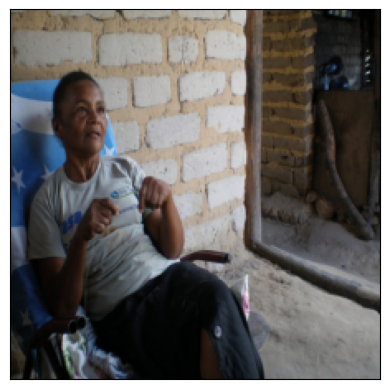

In [44]:
def TestSample(index, validation_images_list, features_image, model,
               index_to_word_dict,
            #    word_to_embedding_dict,
                word_embedder,
               sequence_length=40,
               endOfSeqIndex=0,
               use_cuda=True):
    sample_filename = validation_images_list[index]
    sample_feature_extraction_Tsr = torch.FloatTensor(features_image[sample_filename])
    if use_cuda:
        sample_feature_extraction_Tsr = sample_feature_extraction_Tsr.cuda()
    sample_words = model.Caption(
        feature_extraction_Tsr=sample_feature_extraction_Tsr,
        max_length=sequence_length,
        # word_to_embedding_dict=word_to_embedding_dict,
        word_embedder = word_embedder,
        index_to_word_dict=index_to_word_dict,
        startseq_idx = word_to_index_dict['<startseq>'],
        endseq_idx = word_to_index_dict['<endseq>'],
        notset_idx = word_to_index_dict['<notset>'],
        use_cuda=use_cuda
    )
    return sample_words
validation_sample_0_Ndx = 0
validation_sample_100_Ndx = 100
validation_images_list = list(val_mapping.keys())
test_images_list = list(test_mapping.keys())
img_tensor = readImage(os.path.join(IMAGES_PATH, validation_images_list[validation_sample_0_Ndx]))
show(img_tensor)

In [45]:
wandb.init(project = "ProjectGenCap", config={
    "learning_rate": 0.0003,
    "batch_size": 16,
    "epochs": 100,
    "model": "LSTM",
    "embedding_dim": 128,
    "lr_scheduler":  "Plateau 50, *0.1",
    "optimizer" : "ADAM",
    "weight_decay": "1e-5",
    "train_ratio":0.85,
    "val_ratio": 0.1,
})

In [46]:
best_model_filepath = os.path.join(PROJECT_DIR, 'models', 'lstm_1_lr_decay_eb_change.pth')
startseq_index = word_to_index_dict['<startseq>']
endseq_index = word_to_index_dict['<endseq>']
weight = torch.ones(vocabulary_size).cuda()  # Khởi tạo trọng số 1 cho tất cả token
weight[endseq_index] = 0.1  # Giảm trọng số cho <endseq>


In [47]:
if use_cuda:
    lstm_model = lstm_model.cuda() 
    # word_embedder = word_embedder.cuda()
# parameters = filter(lambda p: p.requires_grad, lstm_model.parameters())

parameters = list(filter(lambda p: p.requires_grad, lstm_model.parameters())) + \
             list(filter(lambda p: p.requires_grad, word_embedder.parameters()))

optimizer = torch.optim.Adam(parameters, lr=0.0003,weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                 mode='min',  # Giảm LR khi metric không giảm
                                                 factor=0.1,  # LR giảm 10 lần
                                                 patience=50,  # Chờ 50 epoch không cải thiện
                                                 verbose=True)  # In log nếu LR giảm

lossFcn = nn.CrossEntropyLoss(weight=weight)

train_dataLoader = DataLoader(lstm_train_dataset, batch_size=16, shuffle=True)
validation_dataLoader = DataLoader(lstm_val_dataset, batch_size=lstm_val_dataset.__len__())

lowestValidationLoss = sys.float_info.max

for epoch in range(1, 1000+1):
    lstm_model.train()
    word_embedder.train()
    loss_sum = 0.0
    numberOfBatches = 0
    
    # so sánh từ đoán được và từ thực tế next index
    for ((feature_extraction_Tsr, embedded_chop_gen_cap_Tsr), next_word_index) in train_dataLoader:
        if numberOfBatches % 20 == 1:
            print (".", end="", flush=True)
        if use_cuda:
            feature_extraction_Tsr = feature_extraction_Tsr.cuda()
            embedded_chop_gen_cap_Tsr = embedded_chop_gen_cap_Tsr.cuda()
            next_word_index = next_word_index.cuda()

        predicted_next_word = lstm_model(feature_extraction_Tsr, embedded_chop_gen_cap_Tsr)
        
        mask = torch.ones_like(predicted_next_word, dtype=torch.bool)
        mask[:, startseq_index] = False
        masked_logits = predicted_next_word.masked_fill(~mask, float('-inf'))
        
        optimizer.zero_grad()
        loss = lossFcn(masked_logits, next_word_index)
       
        # loss = lossFcn(predicted_next_word, next_word_index)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        numberOfBatches += 1
    train_loss = loss_sum/numberOfBatches
    print ("\nepoch {}: train_loss = {}".format(epoch, train_loss))

    # Validation
    lstm_model.eval()
    word_embedder.eval()
    sample_0_words = TestSample(validation_sample_0_Ndx, validation_images_list, features_image, lstm_model,
       index_to_word_dict,
# word_to_embedding_dict,
        word_embedder=word_embedder,
        sequence_length=40,
        endOfSeqIndex=0,
        use_cuda=use_cuda)
    print ("sample_0_words = {}".format(sample_0_words))
    sample_100_words = TestSample(validation_sample_100_Ndx, validation_images_list, features_image, lstm_model,
       index_to_word_dict,
# word_to_embedding_dict,
        word_embedder=word_embedder,
        sequence_length=40,
        endOfSeqIndex=0,
        use_cuda=use_cuda)
    print ("sample_100_words = {}".format(sample_100_words))
    
    for ((validation_feature_extraction_Tsr, validation_embedded_chop_gen_cap_Tsr), validation_next_word_index) in validation_dataLoader:
        if use_cuda:
            validation_feature_extraction_Tsr = validation_feature_extraction_Tsr.cuda()
            validation_embedded_chop_gen_cap_Tsr = validation_embedded_chop_gen_cap_Tsr.cuda()
            validation_next_word_index = validation_next_word_index.cuda()
        validation_predicted_next_word = lstm_model(validation_feature_extraction_Tsr, validation_embedded_chop_gen_cap_Tsr)
        validation_loss = lossFcn(validation_predicted_next_word, validation_next_word_index).item()
        
    print ("validation_loss = {}".format(validation_loss))

    if validation_loss < lowestValidationLoss:
        lowestValidationLoss = validation_loss
        torch.save(lstm_model.state_dict(), best_model_filepath)
    lr_scheduler.step(validation_loss)
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "lowest_validation_loss": lowestValidationLoss,
    })
wandb.finish()

......................
epoch 1: train_loss = 8.359458620603695
sample_0_words = ['<startseq>', 'sledge', 'penzance', 'passage', 'member', 'earphone', 'scalling', 'dirt-covered', 'observer', 'exercise', 'walls', 'stumps', 'riders', 'snake', 'patchy', 'quite', 'more', 'dandelions', 'black-green', '<endseq>']
sample_100_words = ['<startseq>', 'kicker', 'defenders', 'muddy', 'freesbies', 'thrust', 'fishing', 'shovels', 'formally', 'nitro', 'bowing', 'twirling', 'transit', 'pads', 'advertisement', 'examine', 'jogs', 'studies', 'sick', 'stretched', 'housing', 'japanese', 'adventurer', 'onslaught', 'arts-style', 'jersay', 'bar-type', 'undone', 'hedge', 'braces', 'rapids', 'sail', '-ependent', 'facepaint', 'braces', 'cafeteria', '<endseq>']
validation_loss = 7.858659744262695
......................
epoch 2: train_loss = 7.474667707709379
sample_0_words = ['<startseq>', 'cooks', 'moss', 'bright', 'steering', 'single', 'distressed', 'texas', 'saver', 'marine', 'snub', 'dunks', 'walks', 'medatati

KeyboardInterrupt: 

In [48]:
def has_weights_changed(model, initial_state_dict):
    for k, v in model.state_dict().items():
        if not torch.equal(v, initial_state_dict[k]):
            return True  # Phát hiện có sự thay đổi
    return False

# Gọi hàm kiểm tra
weights_changed = has_weights_changed(word_embedder, initial_state_dict)
print("Trọng số đã thay đổi:", weights_changed)

Trọng số đã thay đổi: True


### 5.Evaluation

In [49]:
import os
import sys

# Get the parent directory of the current file (to access the sibling directory)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Add the evaluation directory (sibling of current directory) to sys.path
evaluation_path = os.path.join(parent_dir, "evaluation")
if evaluation_path not in sys.path:
    sys.path.append(evaluation_path)

# Import the BLEU function
try:
    from BLEU import BLEU
    print("Successfully imported BLEU.")
except ModuleNotFoundError as e:
    print(f"Module not found: {e}. Check the path: {evaluation_path}")

######################################################################################



Successfully imported BLEU.


In [50]:
# Load the model that gave the lowest validation loss
best_model_filepath = os.path.join(PROJECT_DIR, 'models', 'lstm_1_lr_decay_eb_change.pth')
lstm_model.load_state_dict(torch.load(best_model_filepath))

# Randomly select some test images
test_image_sample_indices = random.choices(range(len(validation_images_list)), k=3)
lstm_model.eval()

test_sample_filepaths = []
test_sample_captions = []

for test_image_sample_index in test_image_sample_indices:
    sample_words = TestSample(test_image_sample_index, validation_images_list, features_image, lstm_model,
                                index_to_word_dict, word_embedder, sequence_length=40,
                                endOfSeqIndex=0, use_cuda=use_cuda) 
    caption = ' '.join(sample_words)
    test_sample_filepaths.append(os.path.join(IMAGES_PATH, validation_images_list[test_image_sample_index]))
    test_sample_captions.append(caption)
print("Filepath:", test_sample_filepaths)
 
test_references = []
''' reference chứa các cap của 1 ảnh '''
for filepath in test_sample_filepaths:
    file_path = filepath.split('/')                   # windows might be \ instead of /
    file_path = file_path[-1]
    # print(test_mapping[file_path])
    test_references.append(val_mapping[file_path])


for i in range(len(test_references)):
    test_references[i] = [' '.join(clean_and_tokenize(cap)) for cap in test_references[i]]
print(test_references)
print(test_references[0])

# cleaned_generated_captions = [
#     caption.replace("<startseq>", "").replace("<endseq>", "").strip()
#     for caption in test_sample_captions
# ]
    
bleu_scores = []
for generated_caption, references in zip(test_sample_captions, test_references):
    bleu_score = BLEU([references], [generated_caption])
    bleu_scores.append(bleu_score)
    


Filepath: ['../data/flickr8k/Images/247618600_239eeac405.jpg', '../data/flickr8k/Images/3009018821_ba47396e24.jpg', '../data/flickr8k/Images/2636876892_9353521a1c.jpg']
[['<startseq> girl has placed purple cloth over her face while she lies on wooden structure <endseq>', '<startseq> girl is sunning herself with purple towel over her face <endseq>', '<startseq> girl lays on wooden deck with piece of clothing covering her face <endseq>', '<startseq> young woman is laying in the sun with her face covered by purple scarf <endseq>', '<startseq> young woman with purple cloth hiding her face relaxes on wooden deck <endseq>'], ['<startseq> girl in swimming pool playing badminton while lady watches <endseq>', '<startseq> woman in pink bathing suit holds badminton racket while another lady looks on <endseq>', '<startseq> woman sits and watches another woman play in the pool <endseq>', '<startseq> one woman sitting beside the pool while another plays badminton in the pool <endseq>', '<startseq> w

<startseq> kid brown on beads are the retreived child collars little show holds in boogie-board baked is beach grey-blue some each braces tennis walks goaltender plays look young fringe girls looks floaties faux as sidewalks against fit mothers with cluster
BLEU1 Score: 0.175
BLEU2 Score: 0.0406849655489321
BLEU3 Score: 0.020827305921683678
BLEU4 Score: 0.011895847309770785


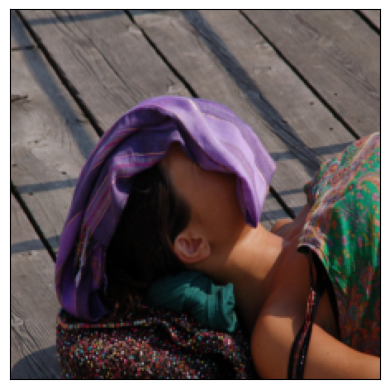

In [51]:
print (test_sample_captions[0])
bleu = bleu_scores[0]
print(f"BLEU1 Score: {bleu.bleu1()}")
print(f"BLEU2 Score: {bleu.bleu2()}")
print(f"BLEU3 Score: {bleu.bleu3()}")
print(f"BLEU4 Score: {bleu.bleu4()}")
show(readImage(test_sample_filepaths[0]))

<startseq> girl high deep water in ocean forcing pool swordfighting sand playing is jump into playing wheelie load ramp slouching boy his drilling woman girls and lady tennis rustic the girl served concentrates hockey at are elder reading are young
BLEU1 Score: 0.225
BLEU2 Score: 0.07595545253127502
BLEU3 Score: 0.03952896987088197
BLEU4 Score: 0.022986501653332967


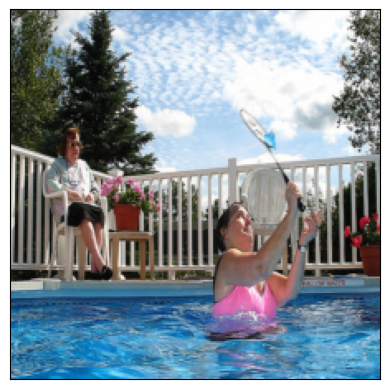

In [52]:
print (test_sample_captions[1])
bleu = bleu_scores[1]
print(f"BLEU1 Score: {bleu.bleu1()}")
print(f"BLEU2 Score: {bleu.bleu2()}")
print(f"BLEU3 Score: {bleu.bleu3()}")
print(f"BLEU4 Score: {bleu.bleu4()}")
show(readImage(test_sample_filepaths[1]))

<startseq> cross-legged bleachers lines spotting snow the are wearing swing newspapers thinks backround sign threshold fabric two on snowy romp big tunnel slide train motorcycles off at the piano and girl yard housekeeping three black rope the with window yellow
BLEU1 Score: 0.10000000000000002
BLEU2 Score: 0.030754943126201372
BLEU3 Score: 0.017315320721479528
BLEU4 Score: 0.010342746230056077


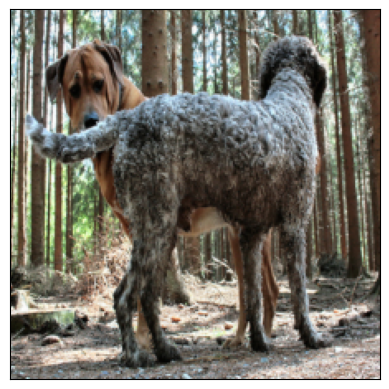

In [53]:
print (test_sample_captions[2])
bleu = bleu_scores[2]
print(f"BLEU1 Score: {bleu.bleu1()}")
print(f"BLEU2 Score: {bleu.bleu2()}")
print(f"BLEU3 Score: {bleu.bleu3()}")
print(f"BLEU4 Score: {bleu.bleu4()}")
show(readImage(test_sample_filepaths[2]))


In [54]:

def generate_and_evaluate_captions(test_images_list, test_mapping, features_extraction, model, 
                                   index_to_word_dict, word_embedder, word_to_index_dict, 
                                   output_file, sequence_length=40, use_cuda=True):
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        csv_writer = csv.writer(csvfile)
        csv_writer.writerow(['image','real_cap', 'caption_gen', 'bleu_score1'])  # Ghi header

        for img_filename in test_images_list:
            # Lấy đặc trưng của ảnh
            feature_extraction_Tsr = features_extraction[filename]
            if use_cuda:
                feature_extraction_Tsr = feature_extraction_Tsr.cuda()

            # Sinh caption
            sample_words = model.Caption(
                feature_extraction_Tsr=feature_extraction_Tsr,
                max_length=sequence_length,
                word_embedder=word_embedder,
                index_to_word_dict=index_to_word_dict,
                startseq_idx=word_to_index_dict['<startseq>'],
                endseq_idx=word_to_index_dict['<endseq>'],
                notset_idx=word_to_index_dict['<notset>'],
                use_cuda=use_cuda
            )
            generated_caption = ' '.join(sample_words)

            # Lấy reference captions
            references = test_mapping[img_filename]
            cleaned_references = [' '.join(clean_and_tokenize(cap)) for cap in references]

            # Tính BLEU-1
            bleu_score = BLEU([cleaned_references], [generated_caption])

            # Ghi kết quả vào file
            csv_writer.writerow([img_filename,test_mapping[img_filename][0],  generated_caption, bleu_score.bleu1()])

    print(f"Results saved to {output_file}")

# Đường dẫn đến file kết quả
output_csv_path = os.path.join(PROJECT_DIR,'data', 'test_captions_results.csv')

# Gọi hàm sinh captions và tính BLEU-1
generate_and_evaluate_captions(
    test_images_list=test_images_list,
    test_mapping=test_mapping,
    features_extraction=features_image,
    model=lstm_model,
    index_to_word_dict=index_to_word_dict,
    word_embedder=word_embedder,
    word_to_index_dict=word_to_index_dict,
    output_file=output_csv_path,
    sequence_length=40,
    use_cuda=use_cuda
)

Results saved to ../data/test_captions_results.csv
